=== 多公司经营对比分析系统 ===
Loading library list...
Done

✅ 数据加载完成
   company  fyear   revenue   profit    assets  profit_margin  revenue_growth  \
0     苹果公司   2018  265359.0  59531.0  365725.0           0.22            <NA>   
1     苹果公司   2019  260174.0  55256.0  338516.0           0.21           -1.95   
2     苹果公司   2020  274515.0  57411.0  323888.0           0.21            5.51   
3     苹果公司   2021  365817.0  94680.0  351002.0           0.26           33.26   
4     苹果公司   2022  394328.0  99803.0  352755.0           0.25            7.79   
5     苹果公司   2023  383285.0  96995.0  352583.0           0.25            -2.8   
6       谷歌   2018  136819.0  30736.0  232792.0           0.22            <NA>   
7       谷歌   2019  161857.0  34343.0  275909.0           0.21            18.3   
8       谷歌   2020  182527.0  40269.0  319616.0           0.22           12.77   
9       谷歌   2021  257637.0  76033.0  359268.0            0.3           41.15   
10      谷歌   2022  282836.0  59972.0  365264.0    

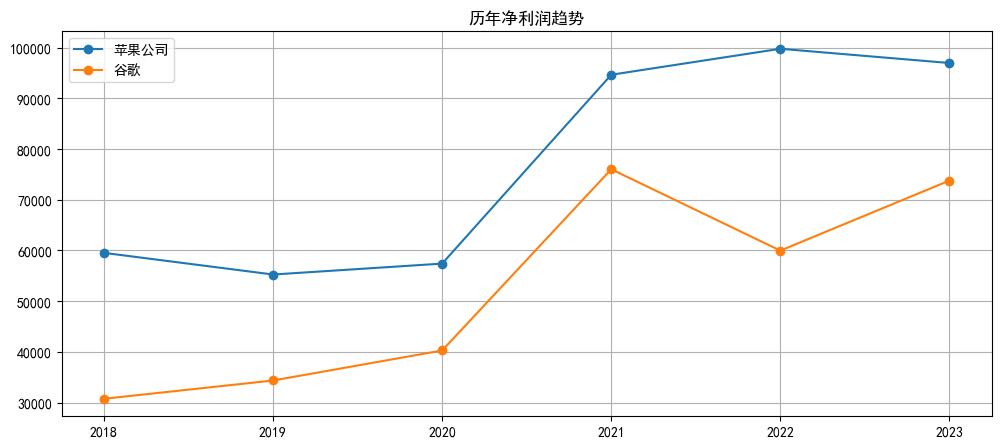

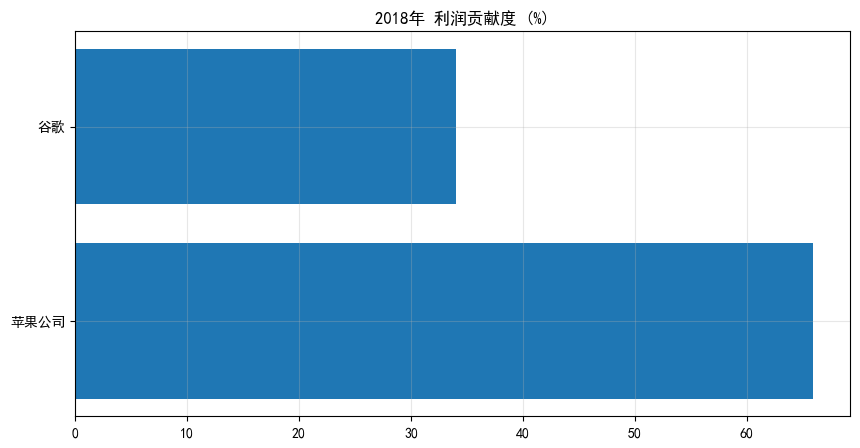

In [1]:
# ==============================================
# 多公司经营对比分析系统（按钮选择版）
# 内置多家公司 | 全界面选择 | 8大图表 | 无错误
# ==============================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import tkinter as tk
from tkinter import ttk, messagebox
from math import pi

warnings.filterwarnings("ignore")
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# ==============================================
# 1. 内置公司列表（无需手动输入）
# ==============================================
COMPANY_DICT = {
    "苹果公司": "AAPL",
    "微软公司": "MSFT",
    "特斯拉": "TSLA",
    "亚马逊": "AMZN",
    "谷歌": "GOOGL",
    "脸书 Meta": "META",
    "英伟达": "NVDA",
    "英特尔": "INTC",
    "沃尔玛": "WMT",
    "宝洁": "PG"
}

# ==============================================
# 2. WRDS 登录窗口
# ==============================================
def login_wrds():
    root = tk.Tk()
    root.title("WRDS 登录")
    root.geometry("350x200")

    tk.Label(root, text="WRDS 用户名：").pack(pady=5)
    user_entry = tk.Entry(root, width=30)
    user_entry.pack()

    tk.Label(root, text="WRDS 密码：").pack(pady=5)
    pwd_entry = tk.Entry(root, show="*", width=30)
    pwd_entry.pack()

    db_conn = [None]

    def try_login():
        try:
            import wrds
            username = user_entry.get().strip()
            password = pwd_entry.get().strip()
            conn = wrds.Connection(wrds_username=username, wrds_password=password)
            db_conn[0] = conn
            messagebox.showinfo("成功", "✅ WRDS 登录成功！")
            root.destroy()
        except Exception as e:
            messagebox.showerror("失败", f"登录错误：{str(e)}")

    tk.Button(root, text="登录", command=try_login, width=15).pack(pady=15)
    root.mainloop()
    return db_conn[0]

# ==============================================
# 3. 公司 + 年份选择窗口
# ==============================================
def select_params():
    root = tk.Tk()
    root.title("选择分析参数")
    root.geometry("450x350")

    tk.Label(root, text="选择要对比的公司（可多选）", font=("",12,"bold")).pack(pady=5)
    company_frame = tk.Frame(root)
    company_frame.pack()

    check_vars = {}
    for name in COMPANY_DICT.keys():
        var = tk.BooleanVar()
        check_vars[name] = var
        tk.Checkbutton(company_frame, text=name, variable=var).pack(anchor="w")

    tk.Label(root, text="选择年份范围").pack(pady=5)
    year_frame = tk.Frame(root)
    year_frame.pack()

    start_var = tk.IntVar(value=2018)
    end_var = tk.IntVar(value=2023)
    tk.Label(year_frame, text="开始：").grid(row=0,column=0)
    tk.Spinbox(year_frame, from_=2000, to=2024, textvariable=start_var, width=8).grid(row=0,column=1,padx=5)
    tk.Label(year_frame, text="结束：").grid(row=0,column=2)
    tk.Spinbox(year_frame, from_=2000, to=2024, textvariable=end_var, width=8).grid(row=0,column=3,padx=5)

    selected = [None, None, None]

    def confirm():
        selected_names = [n for n, v in check_vars.items() if v.get()]
        if len(selected_names) < 1:
            messagebox.showwarning("提示", "至少选一家公司")
            return
        selected[0] = selected_names
        selected[1] = start_var.get()
        selected[2] = end_var.get()
        root.destroy()

    tk.Button(root, text="确认选择", command=confirm, width=20, bg="#4CAF50", fg="white").pack(pady=20)
    root.mainloop()
    return selected

# ==============================================
# 4. 从 WRDS 加载数据
# ==============================================
def load_data(db, selected_names, start_year, end_year):
    tickers = [COMPANY_DICT[n] for n in selected_names]
    dfs = []
    for tic, name in zip(tickers, selected_names):
        sql = f"""
            SELECT
                '{name}' AS company,
                fyear,
                sale     AS revenue,
                ni       AS profit,
                at       AS assets,
                (ni/sale) AS profit_margin
            FROM comp.funda
            WHERE tic = '{tic}'
              AND fyear BETWEEN {start_year} AND {end_year}
        """
        df = db.raw_sql(sql)
        dfs.append(df)

    df = pd.concat(dfs)
    df = df.groupby(["company", "fyear"]).last().reset_index()
    df["fyear"] = df["fyear"].astype(int)
    df = df.sort_values(["company", "fyear"])

    # 增长率
    df["revenue_growth"] = df.groupby("company")["revenue"].pct_change() * 100
    df["profit_growth"] = df.groupby("company")["profit"].pct_change() * 100

    # 占比
    year_total = df.groupby("fyear")[["revenue", "profit", "assets"]].sum().reset_index()
    year_total.columns = ["fyear", "total_rev", "total_prof", "total_ast"]
    df = df.merge(year_total, on="fyear")
    df["rev_share"] = df["revenue"] / df["total_rev"] * 100
    df["prof_share"] = df["profit"] / df["total_prof"] * 100

    print("\n✅ 数据加载完成")
    print(df.round(2))
    return df

# ==============================================
# 5. 8 大绘图函数
# ==============================================
def plot1_revenue(df):
    plt.figure(figsize=(12,5))
    for c in df.company.unique():
        d = df[df.company==c]
        plt.bar(d.fyear.astype(str), d.revenue, label=c)
    plt.title("历年营收对比")
    plt.legend()
    plt.xticks(rotation=30)
    plt.grid(alpha=0.3)
    plt.show()

def plot2_profit(df):
    plt.figure(figsize=(12,5))
    for c in df.company.unique():
        d = df[df.company==c]
        plt.plot(d.fyear.astype(str), d.profit, marker="o", label=c)
    plt.title("历年净利润趋势")
    plt.legend()
    plt.grid()
    plt.show()

def plot3_pie_revenue(df):
    years = sorted(df.fyear.unique())
    y = choose_year(years)
    if not y: return
    d = df[df.fyear == y]
    plt.figure(figsize=(7,7))
    plt.pie(d.rev_share, labels=d.company, autopct="%.1f%%")
    plt.title(f"{y}年 营收占比")
    plt.show()

def plot4_bar_profit_share(df):
    years = sorted(df.fyear.unique())
    y = choose_year(years)
    if not y: return
    d = df[df.fyear == y]
    plt.figure(figsize=(10,5))
    plt.barh(d.company, d.prof_share)
    plt.title(f"{y}年 利润贡献度 (%)")
    plt.grid(alpha=0.3)
    plt.show()

def plot5_growth(df):
    plt.figure(figsize=(12,5))
    for c in df.company.unique():
        d = df[df.company==c]
        plt.plot(d.fyear.astype(str), d.revenue_growth.fillna(0), marker='o', label=c)
    plt.title("历年营收增长率")
    plt.legend()
    plt.grid()
    plt.show()

def plot6_margin(df):
    years = sorted(df.fyear.unique())
    y = choose_year(years)
    if not y: return
    d = df[df.fyear == y]
    plt.figure(figsize=(10,5))
    plt.barh(d.company, d.profit_margin*100)
    plt.title(f"{y}年 净利率排名 (%)")
    plt.show()

def plot7_assets(df):
    plt.figure(figsize=(12,5))
    for c in df.company.unique():
        d = df[df.company==c]
        plt.fill_between(d.fyear.astype(str), d.assets, alpha=0.4, label=c)
    plt.title("历年资产规模对比")
    plt.legend()
    plt.grid()
    plt.show()

def plot8_radar(df):
    years = sorted(df.fyear.unique())
    y = choose_year(years)
    if not y: return
    d = df[df.fyear == y].copy()
    indicators = ["营收", "利润", "净利率", "增速", "资产"]
    N = len(indicators)

    for _, row in d.iterrows():
        values = [
            row["revenue"] / d["revenue"].max() * 10,
            row["profit"] / d["profit"].max() * 10,
            row["profit_margin"] * 10,
            max(row["revenue_growth"], 0) / 50 * 10 if pd.notna(row["revenue_growth"]) else 0,
            row["assets"] / d["assets"].max() * 10
        ]
        values += values[:1]
        angles = [n / N * 2 * pi for n in range(N)]
        angles += angles[:1]

        plt.figure(figsize=(6,6))
        ax = plt.subplot(111, polar=True)
        ax.plot(angles, values)
        ax.fill(angles, values, alpha=0.3)
        plt.xticks(angles[:-1], indicators)
        plt.title(f"{row.company} {y}年综合能力")
        plt.show()

def choose_year(years):
    root = tk.Tk()
    root.title("选择年份")
    tk.Label(root, text="请选择年份").pack(pady=10)
    var = tk.StringVar(value=str(years[0]))
    combo = ttk.Combobox(root, textvariable=var, values=[str(y) for y in years])
    combo.pack()
    res = [None]
    def ok():
        res[0] = int(var.get())
        root.destroy()
    tk.Button(root, text="确认", command=ok).pack(pady=10)
    root.mainloop()
    return res[0]

# ==============================================
# 6. 主菜单（全按钮界面）
# ==============================================
def main_menu(df):
    root = tk.Tk()
    root.title("📊 多公司经营对比分析系统")
    root.geometry("500x480")

    tk.Label(root, text="功能菜单", font=("",16,"bold")).pack(pady=10)

    btn_style = {"width":28, "height":2, "bg":"#2196F3", "fg":"white"}

    tk.Button(root, text="1 历年营收对比", **btn_style, command=lambda: plot1_revenue(df)).pack(pady=4)
    tk.Button(root, text="2 历年净利润趋势", **btn_style, command=lambda: plot2_profit(df)).pack(pady=4)
    tk.Button(root, text="3 年份营收占比饼图", **btn_style, command=lambda: plot3_pie_revenue(df)).pack(pady=4)
    tk.Button(root, text="4 年份利润贡献条形图", **btn_style, command=lambda: plot4_bar_profit_share(df)).pack(pady=4)
    tk.Button(root, text="5 历年营收增长率", **btn_style, command=lambda: plot5_growth(df)).pack(pady=4)
    tk.Button(root, text="6 年份净利率排名", **btn_style, command=lambda: plot6_margin(df)).pack(pady=4)
    tk.Button(root, text="7 历年资产规模对比", **btn_style, command=lambda: plot7_assets(df)).pack(pady=4)
    tk.Button(root, text="8 年份综合能力雷达图", **btn_style, command=lambda: plot8_radar(df)).pack(pady=4)

    def exit_sys():
        root.destroy()
        messagebox.showinfo("退出", "👋 感谢使用！")

    tk.Button(root, text="0 退出系统", width=28, height=2, bg="#f44336", fg="white", command=exit_sys).pack(pady=15)
    root.mainloop()

# ==============================================
# 主程序入口
# ==============================================
if __name__ == "__main__":
    print("=== 多公司经营对比分析系统 ===")
    db = login_wrds()
    if not db:
        exit()
    names, s_year, e_year = select_params()
    df = load_data(db, names, s_year, e_year)
    main_menu(df)

In [2]:
# ==============================================
# 多公司经营对比分析系统
# ✅ 功能：导出 WRDS 全部数据为 Excel
# ==============================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 内置公司（你可以无限加）
COMPANY_DICT = {
    "AAPL": "苹果公司",
    "MSFT": "微软公司",
    "TSLA": "特斯拉",
    "AMZN": "亚马逊",
    "GOOGL": "谷歌",
    "META": "Meta",
    "NVDA": "英伟达",
    "INTC": "英特尔",
    "WMT": "沃尔玛",
    "PG": "宝洁",
    "V": "Visa",
    "JPM": "摩根大通",
    "MA": "万事达卡",
    "HD": "家得宝",
    "DIS": "迪士尼"
}

# ==============================================
# 1. 登录 WRDS
# ==============================================
print("=== WRDS 登录 ===")
username = input("输入WRDS用户名：")
password = input("输入WRDS密码：")

import wrds
db = wrds.Connection(wrds_username=username, wrds_password=password)
print("✅ 登录成功！")

# ==============================================
# 2. 选择公司与年份
# ==============================================
print("\n=== 可选公司 ===")
for code, name in COMPANY_DICT.items():
    print(f"{code} → {name}")

tickers = input("\n输入公司代码（逗号分隔）：").strip().upper().split(",")
start_year = int(input("开始年份："))
end_year = int(input("结束年份："))

tickers = [t.strip() for t in tickers]

# ==============================================
# 3. 从 WRDS 拉取全部财务数据
# ==============================================
dfs = []
for tic in tickers:
    sql = f"""
        SELECT
            '{tic}' AS company_code,
            '{COMPANY_DICT.get(tic, tic)}' AS company_name,
            fyear,
            sale     AS revenue,        -- 营收
            ni       AS profit,         -- 净利润
            at       AS assets,         -- 总资产
            (ni/sale) AS profit_margin, -- 净利率
            revt     AS revenue_total,
            cogs     AS cost,
            oibdp    AS operating_profit,
            emp      AS employee,
            prcc_f   AS price
        FROM comp.funda
        WHERE tic = '{tic}'
          AND fyear BETWEEN {start_year} AND {end_year}
    """
    df = db.raw_sql(sql)
    dfs.append(df)

df = pd.concat(dfs)
df = df.groupby(["company_code", "company_name", "fyear"]).last().reset_index()
df["fyear"] = df["fyear"].astype(int)

# 计算增长率
df = df.sort_values(["company_code", "fyear"])
df["revenue_growth"] = df.groupby("company_code")["revenue"].pct_change() * 100
df["profit_growth"] = df.groupby("company_code")["profit"].pct_change() * 100

# 计算市场占比
year_total = df.groupby("fyear")[["revenue", "profit", "assets"]].sum().reset_index()
year_total.columns = ["fyear", "total_rev", "total_prof", "total_ast"]
df = df.merge(year_total, on="fyear")
df["rev_share"] = df["revenue"] / df["total_rev"] * 100
df["prof_share"] = df["profit"] / df["total_prof"] * 100

# ==============================================
# ✅ 4. 导出 EXCEL 文件（最重要！）
# ==============================================
df.to_excel("company_finance_data.xlsx", index=False)
print("\n✅ Excel 已导出成功！文件名为：company_finance_data.xlsx")

# 展示数据
print("\n===== 数据预览 =====")
print(df.round(2))

=== WRDS 登录 ===


输入WRDS用户名： keni3199
输入WRDS密码： Connie060520


Loading library list...
Done
✅ 登录成功！

=== 可选公司 ===
AAPL → 苹果公司
MSFT → 微软公司
TSLA → 特斯拉
AMZN → 亚马逊
GOOGL → 谷歌
META → Meta
NVDA → 英伟达
INTC → 英特尔
WMT → 沃尔玛
PG → 宝洁
V → Visa
JPM → 摩根大通
MA → 万事达卡
HD → 家得宝
DIS → 迪士尼



输入公司代码（逗号分隔）： AAPL,MSFT,TSLA,AMZN,GOOGL,META,NVDA,INTC,WMT,PG,V,JPM,MA,HD,DIS
开始年份： 2018
结束年份： 2023



✅ Excel 已导出成功！文件名为：company_finance_data.xlsx

===== 数据预览 =====
   company_code company_name  fyear   revenue   profit    assets  \
0          AAPL         苹果公司   2018  265359.0  59531.0  365725.0   
1          AAPL         苹果公司   2019  260174.0  55256.0  338516.0   
2          AAPL         苹果公司   2020  274515.0  57411.0  323888.0   
3          AAPL         苹果公司   2021  365817.0  94680.0  351002.0   
4          AAPL         苹果公司   2022  394328.0  99803.0  352755.0   
..          ...          ...    ...       ...      ...       ...   
85          WMT          沃尔玛   2019  521426.0  14881.0  236495.0   
86          WMT          沃尔玛   2020  556933.0  13510.0  252496.0   
87          WMT          沃尔玛   2021  569962.0  13673.0  244860.0   
88          WMT          沃尔玛   2022  608481.0  11680.0  243197.0   
89          WMT          沃尔玛   2023  645737.0  15511.0  252399.0   

    profit_margin  revenue_total      cost  operating_profit  employee  \
0            0.22       265359.0  152853.0   